In [59]:
import torch
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegFileWriter, FuncAnimation

In [60]:
device= 'cuda'
dtype= torch.float32
H=96
W=96

class gaussian:
    def __init__(self, device, dtype, count):
        self.mu =  (-1.0 + 2.0 * torch.rand((count,2), device=device, dtype=dtype)).detach().requires_grad_(True)
        self.alpha = (torch.rand(count, device=device, dtype=dtype)).detach().requires_grad_(True)
        self.color= (torch.rand((count, 3), device=device, dtype=dtype)).detach().requires_grad_(True)
        self.sigma = (0.8*torch.rand((count,2), device=device, dtype=dtype)).detach().requires_grad_(True)
        self.radian = (2.0 * torch.pi * torch.rand(count, device=device, dtype=dtype)).detach().requires_grad_(True)

def edge(v0,v1,P):
    return ((P[...,0] - v0[...,0]) *  (v1[...,1] - v0[...,1])) - ((P[...,1] - v0[...,1]) *  (v1[...,0] - v0[...,0]))

def Get_NDC_Points(H, W, device):
    x = torch.arange(W, device=device)
    y = torch.arange(H, device=device)

    Y,X = torch.meshgrid([y,x], indexing="ij")
    Y = torch.flip(Y, dims=[0])

    NDCX = (((X + 0.5) / W) * 2.0) - 1.0
    NDCY = (((Y + 0.5) / H) * 2.0) - 1.0

    P = torch.stack([NDCX, NDCY],dim=-1 )

    return P

def Render_Hard_Edge(vertices, colors, H, W):
    P = Get_NDC_Points(H,W, vertices.device)
    triangle_count = int(vertices.shape[0] // 3)
    image = torch.zeros((H,W,3), device = vertices.device, dtype=vertices.dtype)
    for i in range(triangle_count):
        i0,i1,i2= i*3, i*3+1, i*3+2
        v0, v1, v2 = vertices[i0], vertices[i1],vertices[i2]
        c0, c1, c2 = colors[i0], colors[i1],colors[i2]

        area = edge(v0, v1, v2)
        s = 1.0 if area >=0.0 else -1.0
        area = torch.where(torch.abs(area) < 1e-12, s * torch.tensor(1e-12,device=area.device), area)
        w2 = edge(v0, v1, P) / area
        w0 = edge(v1, v2, P) / area
        w1 = edge(v2, v0, P) / area
        inside = (w0 >= 0) & (w1>= 0.0) & (w2>=0.0)

        rgbs = (w0[...,None] * c0 + w1[...,None] * c1 + w2[...,None] * c2)
        image[inside] += rgbs[inside]
        image = torch.clamp(image, 0.0 , 1.0)
    return image


def Render_Gaussian_(image, g : gaussian, H, W):
    P = Get_NDC_Points(H,W, g.mu.device)
    gaussian_count = g.mu.shape[0]
    for g_idx in range(gaussian_count):
        tempP = torch.stack([P[...,0] - g.mu[g_idx,0], P[...,1] - g.mu[g_idx,1]],dim=-1)
   
        c = torch.cos(g.radian[g_idx])
        s = torch.sin(g.radian[g_idx])
    
        R = torch.stack([
            torch.stack([c, -s]),
            torch.stack([s,  c])
        ])

        inv_sig_x = 1.0 / (1e-8 + ( g.sigma[g_idx,0]* g.sigma[g_idx,0]))
        inv_sig_y = 1.0 / (1e-8 + ( g.sigma[g_idx,1]* g.sigma[g_idx,1]))
        zero_x = torch.zeros_like(inv_sig_x)
        zero_y = torch.zeros_like(inv_sig_y)    

        SSt = torch.stack([
            torch.stack([inv_sig_x, zero_x]),
            torch.stack([zero_y, inv_sig_y])
        ])

        inv_sigma = R @ SSt @ R.T

        D = inv_sigma @ tempP[...,None]
        D = D.reshape((H,W,2))
        gaussian = torch.exp(-0.5 * torch.sum(tempP * D, dim=-1))

        rgbs = ( g.color[g_idx] *  g.alpha[g_idx]) * gaussian[...,None]

        image[...] += rgbs[...]
        image = torch.clamp(image, 0.0, 1.0)
    return image


In [61]:
g_count = 40
g = gaussian(device, dtype, g_count)
image = torch.zeros((H,W,3), device=device, dtype=dtype)
image =  Render_Gaussian_(image, g, H, W)

v0 = [-0.6, -0.7]
v1 = [-0.1, 0.5]
v2 = [0.5, -0.8]
v3 = [0.6, 0.7]

c0 = [1.0,0.0,0.0]
c1 = [0.0,1.0,-.0]
c2 = [0.0,0.0,1.0]
c3 = [1.0,1.0,1.0]

vertices = torch.tensor([v0, v1,v2,v1,v3,v2],
                         dtype=dtype, device=device)
colors = torch.tensor([c0, c1,c2,c1,c3,c2],
                        dtype=dtype, device=device)


target = Render_Hard_Edge(vertices, colors, H, W)

In [62]:
optimizer = torch.optim.Adam([g.mu,g.alpha,g.color,g.sigma, g.radian], lr=0.01)
frames=  []
train_time = 300

for step in range(train_time):
    optimizer.zero_grad()
    image = torch.zeros((H,W,3), device=device, dtype=dtype)
    image = Render_Gaussian_(image,g,H,W)
    loss = torch.mean((target - image)**2)
    loss.backward()

    optimizer.step()
    frames.append(image)


anim_fig, anim_ax = plt.subplots(figsize=(6,6))
anim_ax.set_title('Gaussian Training')
anim_ax.axis('off')
img = anim_ax.imshow(frames[0].cpu().detach().numpy(), vmin=0.0, vmax=1.0, interpolation="nearest")
text = anim_ax.text(0.5,-0.05, f"Iteration : 0", ha = 'center', fontsize=12,transform=anim_ax.transAxes)


def update_anim(idx):
    img.set_array(frames[idx].cpu().detach().numpy())
    text.set_text(f"Iteration : {idx}")

    return [img , text]

fps =30
filename='Gaussian_Training_Result.mp4'

writer = FFMpegFileWriter(fps=fps,bitrate=1800)
anim = FuncAnimation(anim_fig, update_anim, frames=len(frames), interval=1000/fps, blit=True)

anim.save(filename,writer)
plt.close(anim_fig)

torch.Size([96, 96, 1])


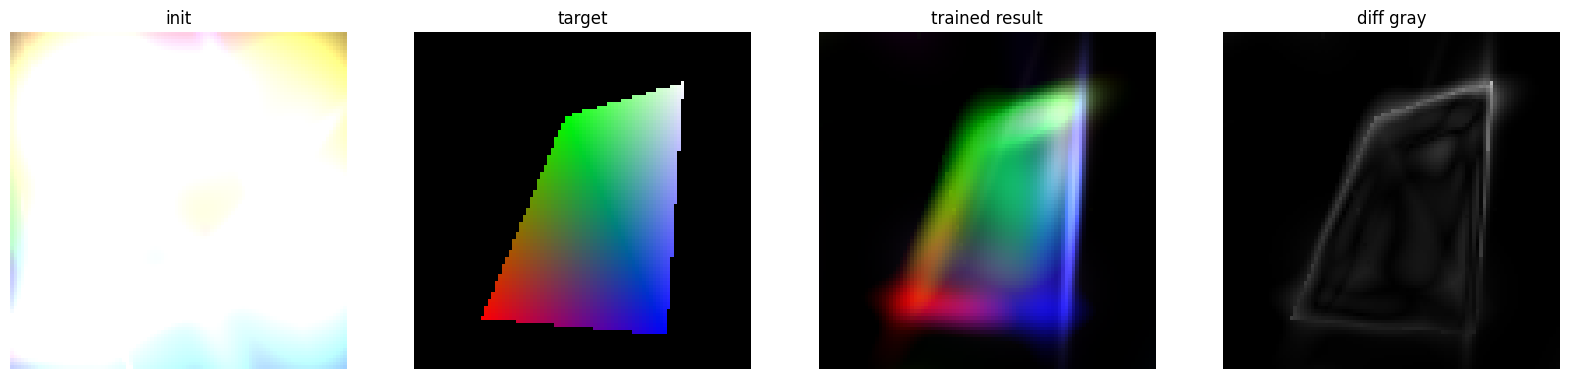

In [ ]:
c = 4
fig, ax = plt.subplots(1,c,figsize=(20,5))
for i in range(c):
    ax[i].axis('off')

ax[0].set_title('init')
ax[1].set_title('target')
ax[2].set_title('trained result')
ax[3].set_title('diff gray')

target_np = target.cpu().detach().numpy()
final_train_result = frames[-1]
init_image = frames[0]

 
def diff_image(a, b):
    d = torch.abs(a - b)
    d =  0.299 * d[..., 0] + 0.587 * d[..., 1] + 0.114 * d[..., 2]
    gray =  torch.clamp(d, 0.0,1.0)
    gray = gray[...,None]
    return gray


gray = diff_image(target, final_train_result)

print(gray.shape)
ax[0].imshow(init_image.cpu().detach().numpy())
ax[1].imshow(target)
ax[2].imshow(final_train_result.cpu().detach().numpy())
ax[3].imshow(gray.cpu().detach().numpy(), cmap='gray', vmin=0.0, vmax=1.0)

plt.show()